# **Additional Findings: Dengue Lag**

**Purpose**
- Explore potential lagged relationships between dengue incidence and selected predictor variables.

**Dataset**
- Processed CALABARZON dengue dataset with climate, socioeconomic, and environmental variables.

**Process**
- Load the prepared dataset.
- Generate lagged dengue incidence variables.
- Analyze relationships between dengue incidence and predictor variables across lag periods.

**Output**
- Additional findings on the relationship between lagged dengue incidence and dengue risk patterns.

In [2]:
# ============================================================
# ADDITIONAL MODEL: Dengue Incidence Lags (1,2,3)
# Climate + Socioeconomic + Environmental + Incidence Lag
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# =============================
# Load Dataset
# =============================
DATA_PATH = "/Users/alexandrasantos/Downloads/Thesis_Dataset_Processed (Final).xlsx"
df = pd.read_excel(DATA_PATH)


Testing Dengue Incidence Lag1 (with tuning)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV accuracy: 0.8165
Hold-out accuracy: 0.7968
Best params: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 2.0, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.7}

Testing Dengue Incidence Lag2 (with tuning)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV accuracy: 0.7917
Hold-out accuracy: 0.7711
Best params: {'subsample': 1.0, 'reg_lambda': 10.0, 'reg_alpha': 2.0, 'n_estimators': 1200, 'min_child_weight': 12, 'max_depth': 3, 'learning_rate': 0.08, 'gamma': 0, 'colsample_bytree': 0.85}

Testing Dengue Incidence Lag3 (with tuning)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV accuracy: 0.7906
Hold-out accuracy: 0.7772
Best params: {'subsample': 0.7, 'reg_lambda': 10.0, 'reg_alpha': 0.1, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 8, 'learning_

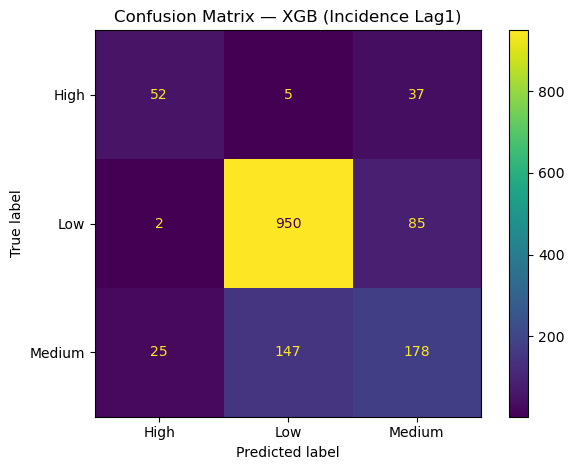

In [6]:
# =============================
# Columns
# =============================
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]

INC_COL = "Dengue Incidence"
GROUP_COL = "Municipality"

LEAKAGE_COLS = ["Dengue Cases", "Death Cases"]  # keep incidence (we need it)

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL, GROUP_COL, INC_COL] + CLIMATE_COLS + SOCIO_COLS + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Remove other leakage variables (keep Dengue Incidence)
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# -----------------------------
# Clean time + sort
# -----------------------------
df = df.dropna(subset=[TARGET_COL, GROUP_COL, INC_COL, "Month", "Year"]).copy()
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"]).copy()
df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

df = df.sort_values([GROUP_COL, "Year", "Month"]).reset_index(drop=True)

# ============================================================
# Create Incidence lags 1,2,3 per Municipality
# ============================================================
for lag in [1, 2, 3]:
    df[f"{INC_COL}_Lag{lag}"] = df.groupby(GROUP_COL)[INC_COL].shift(lag)

# Keep only rows where Lag3 exists (fair comparison across lag1/2/3)
df_lagged = df.dropna(subset=[f"{INC_COL}_Lag3"]).copy()

# ============================================================
# Build X,y for a chosen lag
# ============================================================
def build_xy(dfin: pd.DataFrame, lag: int):
    lag_col = f"{INC_COL}_Lag{lag}"

    X = dfin[
        CLIMATE_COLS + SOCIO_COLS + ENV_COLS + TIME_COLS + [lag_col]
    ].copy()
    y = dfin[TARGET_COL].astype(str).copy()

    # numeric columns
    numeric_cols = [
        # climate
        "Rain", "Temperature", "Relative Humidity",
        # socio numeric
        "Total Population", "Public Healthcare Facilities", "Private Healthcare Facilities",
        # env numeric
        "Forest Cover (%)", "Agricultural Land (%)", "Water Bodies (%)",
        "Open Vegetation (%)", "Built-up / Barren (%)",
        # time
        "Month", "Year",
        # incidence lag
        lag_col
    ]

    for c in numeric_cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

    # categorical columns
    cat_cols = ["Municipal Class", "Settlement Type", "Flood Hazard Level"]
    for c in cat_cols:
        X[c] = X[c].astype(str).fillna("Unknown")

    X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

    # encode target
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    class_names = list(le.classes_)

    return X, y_enc, class_names

# ============================================================
# XGBoost tuning helper
# ============================================================
def tune_xgb(X_train, y_train, num_classes, random_state=42):
    objective = "multi:softprob" if num_classes > 2 else "binary:logistic"
    eval_metric = "mlogloss" if num_classes > 2 else "logloss"

    base_model = XGBClassifier(
        objective=objective,
        eval_metric=eval_metric,
        tree_method="hist",
        random_state=random_state,
        n_jobs=-1
    )

    param_dist = {
        "n_estimators": [400, 800, 1200],
        "max_depth": [3, 4, 5, 6, 8],
        "learning_rate": [0.03, 0.05, 0.08, 0.1],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
        "min_child_weight": [1, 2, 4, 6, 8, 12],
        "gamma": [0, 0.5, 1, 2, 5],
        "reg_alpha": [0, 0.1, 0.5, 1.0, 2.0],
        "reg_lambda": [1.0, 2.0, 5.0, 10.0],
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=60,                 # strong but not too slow
        scoring="accuracy",
        cv=cv,
        verbose=1,
        random_state=random_state,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    return search

# ============================================================
# Compare Lag1 vs Lag2 vs Lag3 (tuned)
# ============================================================
lag_results = []

for lag in [1, 2, 3]:
    print("\n" + "="*72)
    print(f"Testing Dengue Incidence Lag{lag} (with tuning)")
    print("="*72)

    X, y_enc, class_names = build_xy(df_lagged, lag)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc,
        test_size=0.20,
        random_state=42,
        stratify=y_enc
    )

    search = tune_xgb(X_train, y_train, num_classes=len(class_names), random_state=42)
    best_model = search.best_estimator_

    y_pred = best_model.predict(X_test)
    holdout_acc = accuracy_score(y_test, y_pred)

    print("\nBest CV accuracy:", round(search.best_score_, 4))
    print("Hold-out accuracy:", round(holdout_acc, 4))
    print("Best params:", search.best_params_)

    lag_results.append({
        "lag": lag,
        "best_cv_acc": float(search.best_score_),
        "holdout_acc": float(holdout_acc),
        "best_params": search.best_params_
    })

# Pick best lag by CV accuracy (stable choice)
best = sorted(lag_results, key=lambda d: d["best_cv_acc"], reverse=True)[0]
best_lag = best["lag"]

print("\n" + "#"*72)
print(f"BEST INCIDENCE LAG (by CV): Lag{best_lag}")
print("Best CV accuracy:", round(best["best_cv_acc"], 4))
print("Hold-out accuracy:", round(best["holdout_acc"], 4))
print("#"*72)

# ============================================================
# Final tuned model for BEST lag + full evaluation
# ============================================================
X, y_enc, class_names = build_xy(df_lagged, best_lag)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

final_search = tune_xgb(X_train, y_train, num_classes=len(class_names), random_state=42)
final_model = final_search.best_estimator_

print("\nFINAL MODEL (Best lag):", f"Lag{best_lag}")
print("Final Best CV accuracy:", round(final_search.best_score_, 4))
print("Final Best params:", final_search.best_params_)

y_pred = final_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nFinal Hold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title(f"Confusion Matrix — XGB (Incidence Lag{best_lag})")
plt.tight_layout()
plt.show()